In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

In [3]:
import os

print(os.getcwd())      # current folder
print(os.listdir())     # files in current folder

C:\Users\USER\OneDrive\Desktop\movie recom
['.ipynb_checkpoints', 'IMDb Movies India.csv.zip', 'Untitled.ipynb']


In [4]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv.zip", encoding="latin1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'IMDb Movies India.csv.zip', 'Untitled.ipynb']


In [7]:
import zipfile

with zipfile.ZipFile('IMDb Movies India.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted Successfully")

Extracted Successfully


In [8]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'IMDb Movies India.csv', 'IMDb Movies India.csv.zip', 'Untitled.ipynb']


In [9]:
import pandas as pd

df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [11]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [12]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [13]:
df = df[['Name','Year','Duration','Genre',
         'Rating','Votes','Director',
         'Actor 1','Actor 2','Actor 3']]

In [14]:
print(df.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [16]:
df['Year'] = df['Year'].astype(str)

df['Year'] = df['Year'].str.extract(r'(\d{4})')

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [17]:
df['Duration'] = df['Duration'].astype(str)

df['Duration'] = df['Duration'].str.extract(r'(\d+)')

df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [18]:
df['Votes'] = df['Votes'].astype(str)

df['Votes'] = df['Votes'].str.replace(',', '')

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

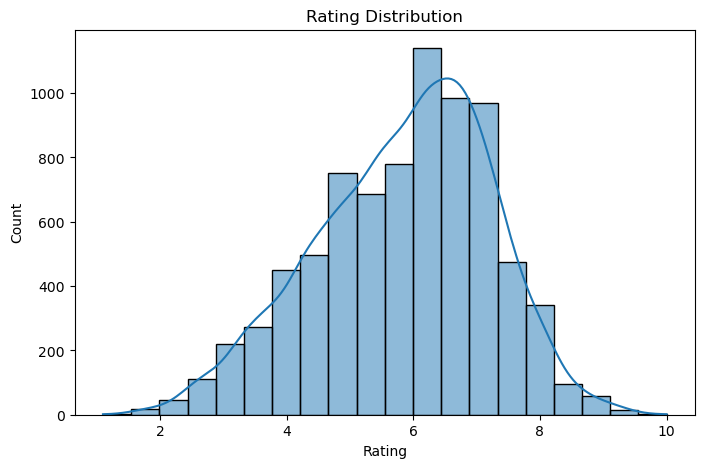

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

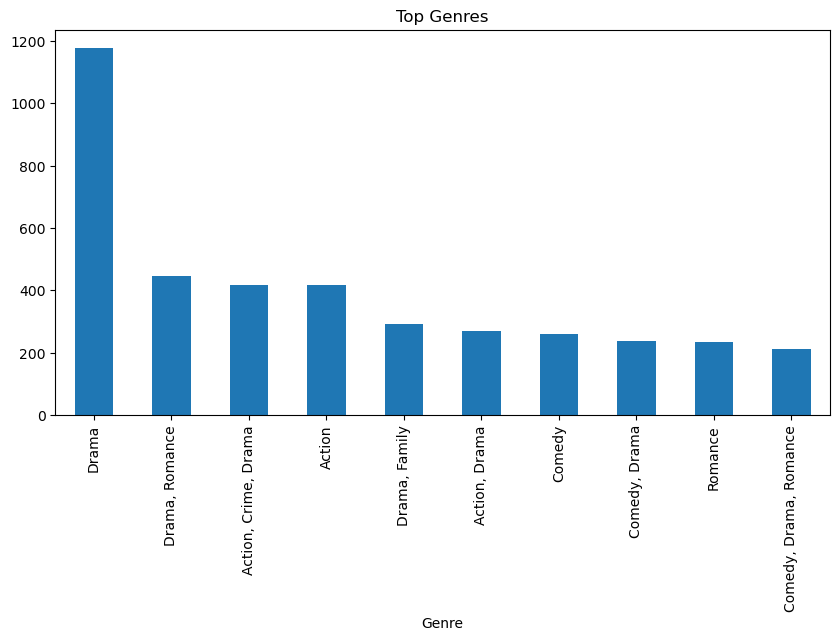

In [22]:
plt.figure(figsize=(10,5))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")
plt.show()

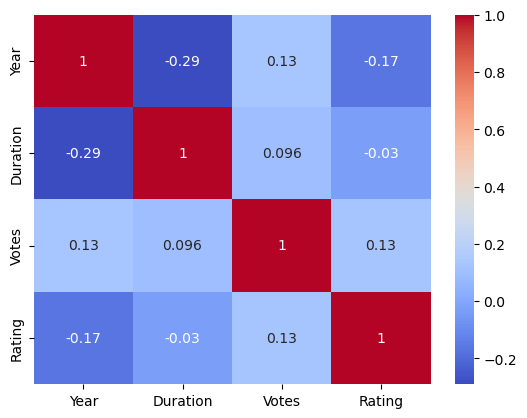

In [23]:
numeric_df = df[['Year','Duration','Votes','Rating']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le_genre = LabelEncoder()
le_director = LabelEncoder()

le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_actor3 = LabelEncoder()

df['Genre'] = le_genre.fit_transform(df['Genre'])

df['Director'] = le_director.fit_transform(df['Director'])

df['Actor 1'] = le_actor1.fit_transform(df['Actor 1'])

df['Actor 2'] = le_actor2.fit_transform(df['Actor 2'])

df['Actor 3'] = le_actor3.fit_transform(df['Actor 3'])

In [30]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
